# WeLoveReviews Sentiment Analysis

## 1. Business Objective

WeLoveReviews wants to compare the sentiment expressed in written customer reviews with the client's approximately **4.5-star average rating**. This analysis creates a repeatable first-pass sentiment view for the account manager, while identifying cases where written language and the human rating disagree.

## 2. Dataset and EDA

The source file contains 500 reviews with `review_id`, `rating`, and `review_text`. We inspect completeness, duplicate IDs, text length, blank text, and the human rating distribution before inference.


In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from app import MODEL_NAME, load_reviews, run_inference, stars_to_sentiment

pd.set_option("display.max_colwidth", 140)
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "reviews.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "reviews_with_sentiment.csv"
reviews = load_reviews(DATA_PATH)
print(f"Loaded {len(reviews):,} reviews from {DATA_PATH}")
print("Columns:", reviews.columns.tolist())
display(reviews.head(3))
print("Shape:", reviews.shape)
print("Missing values:\n", reviews.isna().sum())
print("Duplicate review IDs:", reviews["review_id"].duplicated().sum())
print("Rating distribution:\n", reviews["rating"].value_counts().sort_index())
print("Text length summary:\n", reviews["review_text"].str.len().describe())

reviews["clean_text"] = reviews["review_text"].fillna("").astype(str).str.strip()
print("Blank review texts after strip:", (reviews["clean_text"] == "").sum())
display(reviews[["review_id", "rating", "review_text"]].sample(5, random_state=42))

reviews["human_sentiment"] = reviews["rating"].map(stars_to_sentiment)
human_counts = reviews["human_sentiment"].value_counts().reindex(["NEGATIVE", "NEUTRAL", "POSITIVE"], fill_value=0)
human_percentages = (human_counts / len(reviews) * 100).round(2)
display(pd.DataFrame({"count": human_counts, "percentage": human_percentages}))


Loaded 500 reviews from /workspaces/machine-learning-python-template/data/raw/reviews.csv
Columns: ['review_id', 'rating', 'review_text']


,review_id,rating,review_text
0,1,5,Visited Harbor House Café last weekend. Great spot to work or catch up with friends. Every dish was bursting with flavor. Worth every pe...
1,2,5,Tried Harbor House Café after seeing it recommended online. The coffee was rich and perfectly brewed. Great spot to work or catch up wit...
2,3,5,Tried Harbor House Café after seeing it recommended online. Great spot to work or catch up with friends. The seasonal menu never disappo...


Shape: (500, 3)
Missing values:
 review_id      0
rating         0
review_text    0
dtype: int64
Duplicate review IDs: 0
Rating distribution:
 rating
1     12
2     18
3     38
4     72
5    360
Name: count, dtype: int64
Text length summary:
 count    500.000000
mean     170.170000
std       27.058778
min       86.000000
25%      155.000000
50%      173.000000
75%      189.000000
max      230.000000
Name: review_text, dtype: float64
Blank review texts after strip: 0


,review_id,rating,review_text
361,362,3,"Stopped by Harbor House Café for the first time. The coffee was okay. Average service, no complaints. It's fine for a quick stop."
73,74,5,"Stopped by Harbor House Café for the first time. The place has such a cozy, welcoming vibe. Every dish was bursting with flavor. Five st..."
374,375,5,"Grabbed a quick coffee at Harbor House Café this morning. Service was fast and friendly. The place has such a cozy, welcoming vibe. Reas..."
155,156,4,Grabbed a quick coffee at Harbor House Café this morning. The coffee was rich and perfectly brewed. The staff seemed annoyed to be there...
104,105,5,Grabbed a quick coffee at Harbor House Café this morning. The staff were warm and attentive. The music and decor set the perfect mood. G...


,count,percentage
human_sentiment,,
NEGATIVE,30,6.0
NEUTRAL,38,7.6
POSITIVE,432,86.4


## 3. Model Choice and Sentiment Mapping

The required model is `nlptown/bert-base-multilingual-uncased-sentiment`, a pretrained multilingual BERT classifier that predicts one-to-five-star sentiment. It was trained on product reviews, while this dataset covers service and hospitality experiences, so domain mismatch may cause errors—especially for mixed or context-dependent reviews.

Business mapping:

- **1–2 stars → NEGATIVE**
- **3 stars → NEUTRAL**
- **4–5 stars → POSITIVE**

The model is loaded once in `run_inference()` and reused for all review batches. No training or fine-tuning is performed.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Scored 500 reviews with nlptown/bert-base-multilingual-uncased-sentiment


,review_id,rating,review_text,predicted_stars,predicted_sentiment,confidence
0,1,5,Visited Harbor House Café last weekend. Great spot to work or catch up with friends. Every dish was bursting with flavor. Worth every pe...,5,POSITIVE,0.716958
1,2,5,Tried Harbor House Café after seeing it recommended online. The coffee was rich and perfectly brewed. Great spot to work or catch up wit...,5,POSITIVE,0.982220
2,3,5,Tried Harbor House Café after seeing it recommended online. Great spot to work or catch up with friends. The seasonal menu never disappo...,5,POSITIVE,0.662323


,count,percentage
predicted_sentiment,,
NEGATIVE,47,9.4
NEUTRAL,41,8.2
POSITIVE,412,82.4


Mean human rating: 4.50 / 5
Mean predicted stars: 4.40 / 5


rating
NEGATIVE     30
NEUTRAL      38
POSITIVE    432
Name: count, dtype: int64

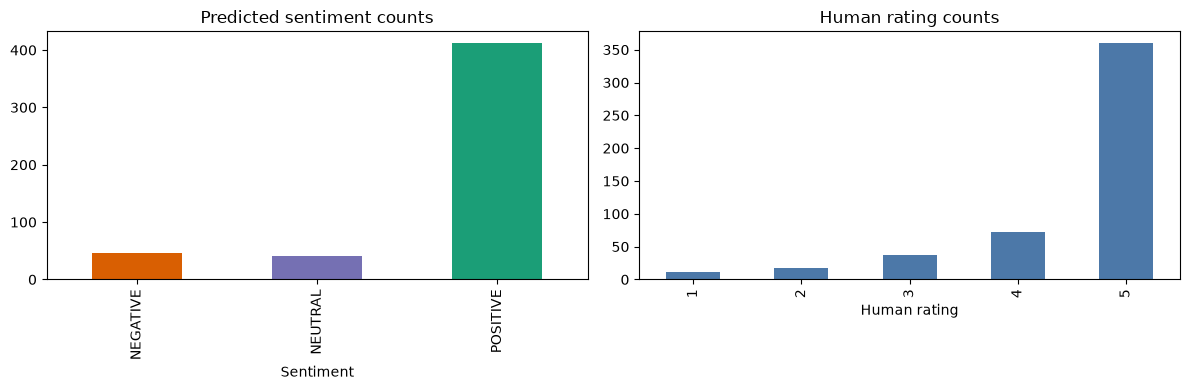

In [5]:
results = run_inference(reviews[["review_id", "rating", "review_text"]])
results.to_csv(OUTPUT_PATH, index=False)
print(f"Scored {len(results):,} reviews with {MODEL_NAME}")
display(results.head(3))

sentiment_order = ["NEGATIVE", "NEUTRAL", "POSITIVE"]
sentiment_counts = results["predicted_sentiment"].value_counts().reindex(sentiment_order, fill_value=0)
sentiment_percentages = (sentiment_counts / len(results) * 100).round(2)
sentiment_summary = pd.DataFrame({"count": sentiment_counts, "percentage": sentiment_percentages})
display(sentiment_summary)

mean_human_rating = results["rating"].mean()
mean_predicted_stars = results["predicted_stars"].mean()
print(f"Mean human rating: {mean_human_rating:.2f} / 5")
print(f"Mean predicted stars: {mean_predicted_stars:.2f} / 5")
display(results["rating"].map(stars_to_sentiment).value_counts().reindex(sentiment_order, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sentiment_counts.plot.bar(ax=axes[0], color=["#d95f02", "#7570b3", "#1b9e77"], title="Predicted sentiment counts")
results["rating"].value_counts().sort_index().plot.bar(ax=axes[1], color="#4c78a8", title="Human rating counts")
axes[0].set_xlabel("Sentiment")
axes[1].set_xlabel("Human rating")
plt.tight_layout()
plt.show()


## 4. Sentiment Inference Results

The next cell runs inference on all 500 reviews, saves the scored dataset, and compares the predicted sentiment distribution with the human rating average.


In [6]:
false_negatives = results[(results["rating"] >= 4) & (results["predicted_stars"] <= 2)].copy()
print(f"False negatives: {len(false_negatives)} ({len(false_negatives) / len(results) * 100:.2f}% of reviews)")
display(false_negatives[["review_id", "rating", "review_text", "predicted_stars", "confidence"]].head(10))
display(false_negatives.sort_values("confidence", ascending=False)[["review_id", "rating", "review_text", "predicted_stars", "confidence"]].head(5))
print("Examples include reviews with strong praise but one criticism, such as an annoyed cashier or slow staff. Product-review training may over-weight isolated negative phrases in these hospitality contexts.")


False negatives: 16 (3.20% of reviews)


,review_id,rating,review_text,predicted_stars,confidence
13,14,4,Tried Harbor House Café after seeing it recommended online. Every dish was bursting with flavor. The team clearly cares about the custom...,1,0.444348
14,15,5,"Every dish was bursting with flavor. The place has such a cozy, welcoming vibe. Already planning my next visit.",1,0.389344
72,73,5,Stopped by Harbor House Café for the first time. Service was fast and friendly. Every dish was bursting with flavor. Worth every penny. ...,1,0.267875
86,87,5,Tried Harbor House Café after seeing it recommended online. The seasonal menu never disappoints. They went out of their way to accommoda...,1,0.324705
137,138,5,Tried Harbor House Café after seeing it recommended online. They went out of their way to accommodate my allergy. The place has such a c...,2,0.275117
199,200,5,Stopped by Harbor House Café for the first time. The music and decor set the perfect mood. Every dish was bursting with flavor. Already ...,2,0.368520
203,204,5,"Came to Harbor House Café for a birthday brunch. Every dish was bursting with flavor. The cashier was rude when i asked about the menu, ...",1,0.349168
253,254,5,Stopped by Harbor House Café for the first time. They went out of their way to accommodate my allergy. Great spot to work or catch up wi...,1,0.364092
269,270,5,Stopped by Harbor House Café for the first time. Our server remembered our names by the second visit. Every dish was bursting with flavo...,1,0.409077
321,322,5,"Every dish was bursting with flavor. The staff seemed annoyed to be there, but honestly the food made up for it. Will definitely be back!",1,0.607708


,review_id,rating,review_text,predicted_stars,confidence
321,322,5,"Every dish was bursting with flavor. The staff seemed annoyed to be there, but honestly the food made up for it. Will definitely be back!",1,0.607708
473,474,5,Stopped by Harbor House Café for the first time. Every dish was bursting with flavor. Service was fast and friendly. This is now my go-t...,1,0.481724
13,14,4,Tried Harbor House Café after seeing it recommended online. Every dish was bursting with flavor. The team clearly cares about the custom...,1,0.444348
408,409,5,Tried Harbor House Café after seeing it recommended online. Every dish was bursting with flavor. Service was fast and friendly. Already ...,1,0.439056
269,270,5,Stopped by Harbor House Café for the first time. Our server remembered our names by the second visit. Every dish was bursting with flavo...,1,0.409077


Examples include reviews with strong praise but one criticism, such as an annoyed cashier or slow staff. Product-review training may over-weight isolated negative phrases in these hospitality contexts.


## 5. False-Negative Analysis

A false negative is defined as a review with `human rating >= 4` and `predicted_stars <= 2`. These examples show where positive customer experiences may be misread because of mixed praise and criticism, negation, unusual wording, or service-specific context.


In [7]:
manual_ids = list(range(1, 21))
manual_labels = {
    1: ("POSITIVE", "Warm visit with flavorful food and good value."),
    2: ("POSITIVE", "Rich coffee, friendly atmosphere, and strong value."),
    3: ("POSITIVE", "Seasonal menu and overall experience are praised."),
    4: ("POSITIVE", "Attentive staff, pleasant setting, and worthwhile visit."),
    5: ("POSITIVE", "Allergy accommodation and excellent food create a positive visit."),
    6: ("POSITIVE", "Welcoming decor and considerate allergy support are praised."),
    7: ("POSITIVE", "Customer care and standout bread make the visit worthwhile."),
    8: ("POSITIVE", "Birthday brunch experience includes friendly service and recognition."),
    9: ("NEUTRAL", "Average food and slow service are balanced by polite staff."),
    10: ("POSITIVE", "A minor service complaint is outweighed by excellent pastries and return intent."),
    11: ("POSITIVE", "Warm staff, attractive space, and an enthusiastic recommendation."),
    12: ("POSITIVE", "Excellent pastries, fast service, and good value are all positive."),
    13: ("POSITIVE", "Seasonal food and atmosphere are described enthusiastically."),
    14: ("POSITIVE", "Strong food praise and customer care outweigh any minor reservation."),
    15: ("POSITIVE", "Flavorful food, cozy atmosphere, and a clear plan to return."),
    16: ("NEUTRAL", "The menu is acceptable but repetitive and the cashier interaction is negative."),
    17: ("POSITIVE", "Good bread and polite staff make this a solid experience despite slowness."),
    18: ("POSITIVE", "Birthday celebration, caring team, and reliable menu are praised."),
    19: ("POSITIVE", "Excellent pastries and overall solid experience outweigh slow service."),
    20: ("POSITIVE", "Allergy accommodation, pleasant space, and value support a strong review."),
}
manual = results[results["review_id"].isin(manual_ids)].copy()
manual["manual_sentiment"] = manual["review_id"].map({review_id: label for review_id, (label, _) in manual_labels.items()})
manual["notes"] = manual["review_id"].map({review_id: note for review_id, (_, note) in manual_labels.items()})
manual["match?"] = manual["manual_sentiment"] == manual["predicted_sentiment"]
manual_validation = manual[["review_id", "rating", "review_text", "predicted_stars", "predicted_sentiment", "manual_sentiment", "match?", "notes"]]
display(manual_validation)
manual_matches = int(manual_validation["match?"].sum())
print(f"Manual validation: {manual_matches}/{len(manual_validation)} matches ({manual_matches / len(manual_validation) * 100:.1f}%)")


,review_id,rating,review_text,predicted_stars,predicted_sentiment,manual_sentiment,match?,notes
0,1,5,Visited Harbor House Café last weekend. Great spot to work or catch up with friends. Every dish was bursting with flavor. Worth every pe...,5,POSITIVE,POSITIVE,True,Warm visit with flavorful food and good value.
1,2,5,Tried Harbor House Café after seeing it recommended online. The coffee was rich and perfectly brewed. Great spot to work or catch up wit...,5,POSITIVE,POSITIVE,True,"Rich coffee, friendly atmosphere, and strong value."
2,3,5,Tried Harbor House Café after seeing it recommended online. Great spot to work or catch up with friends. The seasonal menu never disappo...,5,POSITIVE,POSITIVE,True,Seasonal menu and overall experience are praised.
3,4,5,Visited Harbor House Café last weekend. The staff were warm and attentive. The music and decor set the perfect mood. Worth every penny. ...,5,POSITIVE,POSITIVE,True,"Attentive staff, pleasant setting, and worthwhile visit."
4,5,5,Grabbed a quick coffee at Harbor House Café this morning. They went out of their way to accommodate my allergy. The food was absolutely ...,5,POSITIVE,POSITIVE,True,Allergy accommodation and excellent food create a positive visit.
5,6,5,Stopped by Harbor House Café for the first time. The music and decor set the perfect mood. They went out of their way to accommodate my ...,5,POSITIVE,POSITIVE,True,Welcoming decor and considerate allergy support are praised.
6,7,5,Stopped by Harbor House Café for the first time. The team clearly cares about the customers. The sourdough bread alone is worth the visi...,5,POSITIVE,POSITIVE,True,Customer care and standout bread make the visit worthwhile.
7,8,5,Came to Harbor House Café for a birthday brunch. Great spot to work or catch up with friends. Our server remembered our names by the sec...,5,POSITIVE,POSITIVE,True,Birthday brunch experience includes friendly service and recognition.
8,9,3,"Regular customer at Harbor House Café here. Average sandwiches, nothing to write home about. The staff were polite but a bit slow. It's ...",3,NEUTRAL,NEUTRAL,True,Average food and slow service are balanced by polite staff.
9,10,5,"The pastries were incredible. The staff seemed annoyed to be there, but honestly the food made up for it. This is now my go-to spot.",5,POSITIVE,POSITIVE,True,A minor service complaint is outweighed by excellent pastries and return intent.


Manual validation: 18/20 matches (90.0%)


## 6. Manual Validation

This is a genuine manual review of 20 selected reviews. Each `manual_sentiment` and `notes` value below was explicitly assigned after reading that review's text; it is not copied from the model output or derived from the rating. The mapping is intentionally independent and can disagree with both the rating and prediction.


## 7. Conclusion for the Account Manager

Overall sentiment is strongly positive: 412 of 500 model predictions are positive (82.4%), while the human ratings classify 432 reviews as positive (86.4%) and produce a 4.50/5 average. The model's 4.40/5 predicted-star average is close but slightly more conservative. Sixteen false negatives (3.2%) show that mixed praise and criticism, isolated negative service phrases, and the product-review-to-hospitality domain mismatch deserve human review. The model is suitable for scalable first-pass triage, not for replacing account-manager judgment on ambiguous reviews.
